# Bank Customer Churn Prediction
### Full Pipeline: EDA → Feature Engineering → Logistic Regression → Random Forest → XGBoost (Tuned) → Threshold Strategy → SHAP Explainability → Business Recommendations

**Business context:** A European retail bank is losing customers. This notebook builds a model that identifies customers most likely to churn so the retention team can intervene proactively — before they leave.

**Dataset:** Bank Customer Churn (Kaggle) · 10,000 customers · 11 raw features · 20.4% churn rate

## 1. Setup

In [1]:
import sys
!{sys.executable} -m pip install xgboost shap --quiet

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap

sns.set_theme(style="whitegrid", font_scale=1.05)
COLOR_CHURN  = "#E05C5C"
COLOR_RETAIN = "#4E79A7"
COLOR_RF     = "#F28E2B"

## 2. Business Framing

### What we're predicting
Whether a customer will close their account — a binary classification problem where `Exited = 1` means churned.

### Why accuracy is the wrong metric
With a 20% churn rate, a model that always predicts "Retained" achieves **80% accuracy and catches zero churners**. Accuracy is meaningless here.

**The metrics that matter:**

| Metric | Why it matters for churn |
|---|---|
| **ROC-AUC** | How well the model ranks churners above non-churners across all thresholds |
| **Recall** | What % of actual churners do we catch? Missing one is expensive |
| **Precision** | Of customers we flag, what % actually churn? Too many false alerts waste budget |
| **F1** | Balance between recall and precision for a single comparison number |

Accuracy is deliberately excluded from all model comparisons.

### Business cost framework
Every model decision has a financial consequence:

| Error type | What it means | Cost assumption |
|---|---|---|
| **False Negative** (missed churner) | Customer leaves — lost lifetime value | **£500** |
| **False Positive** (wrong retention offer) | Wasted campaign spend | **£50** |

The **10:1 cost ratio** means we should tolerate more false positives to avoid missing churners. This directly informs our threshold choice later.

## 3. Load Data

In [3]:

df = pd.read_csv("../data/Churn_Modelling.csv")
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Exited'].mean():.1%}  ({df['Exited'].sum():,} churned / {(df['Exited']==0).sum():,} retained)")
print(f"\nMissing values: {df.isnull().sum().sum()} total")
df.head()

Shape: (10000, 11)
Churn rate: 20.4%  (2,037 churned / 7,963 retained)

Missing values: 0 total


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print(df.dtypes)

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


## 4. Exploratory Data Analysis

EDA answers three questions before we model anything:
1. Which features show a visible relationship with churn?
2. Are there data quality issues?
3. What patterns should the model capture — and what should it explain?

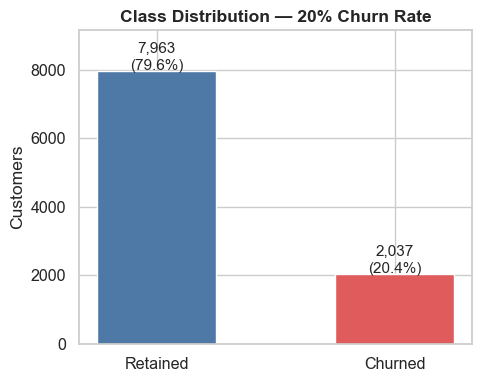

In [5]:
# Class distribution
churn_counts = df["Exited"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Retained", "Churned"], churn_counts.values,
              color=[COLOR_RETAIN, COLOR_CHURN], width=0.5, edgecolor="white")
for bar, count in zip(bars, churn_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f"{count:,}\n({count/len(df):.1%})", ha="center", fontsize=11)
ax.set_title("Class Distribution — 20% Churn Rate", fontweight="bold")
ax.set_ylabel("Customers")
ax.set_ylim(0, churn_counts.max()*1.15)
plt.tight_layout()
plt.show()

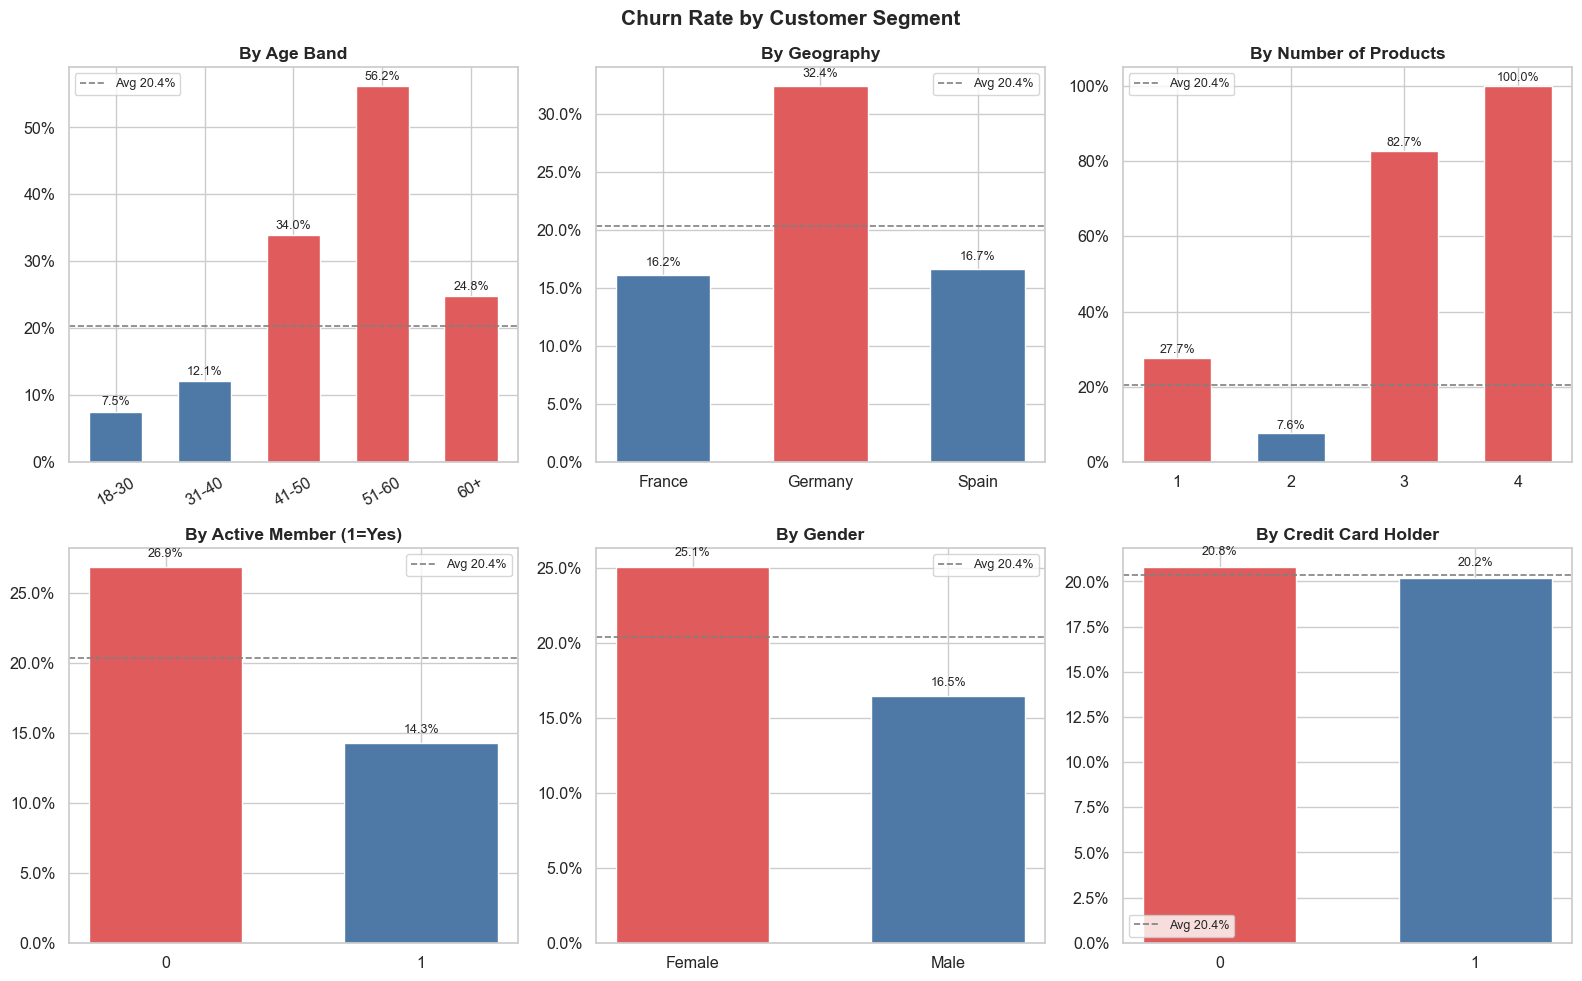

In [6]:
# Churn rate by segment
df_eda = df.copy()
df_eda["AgeBand"] = pd.cut(df_eda["Age"], bins=[18,30,40,50,60,100],
                            labels=["18-30","31-40","41-50","51-60","60+"],
                            include_lowest=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Churn Rate by Customer Segment", fontsize=15, fontweight="bold")

def churn_bar(ax, col, title, rotate=False):
    rates = df_eda.groupby(col, observed=True)["Exited"].mean()
    baseline = df_eda["Exited"].mean()
    colors = [COLOR_CHURN if r > baseline else COLOR_RETAIN for r in rates.values]
    bars = ax.bar(rates.index.astype(str), rates.values*100, color=colors, width=0.6, edgecolor="white")
    ax.axhline(baseline*100, color="grey", linestyle="--", linewidth=1.2,
               label=f"Avg {baseline:.1%}")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(title, fontweight="bold"); ax.set_xlabel(""); ax.legend(fontsize=9)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)
    if rotate:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

churn_bar(axes[0,0], "AgeBand",       "By Age Band",              rotate=True)
churn_bar(axes[0,1], "Geography",     "By Geography")
churn_bar(axes[0,2], "NumOfProducts", "By Number of Products")
churn_bar(axes[1,0], "IsActiveMember","By Active Member (1=Yes)")
churn_bar(axes[1,1], "Gender",        "By Gender")
churn_bar(axes[1,2], "HasCrCard",     "By Credit Card Holder")
plt.tight_layout(); plt.show()

### EDA Summary

The data reveals several strong, structured signals:

- **Germany** churns at 32.4% — double France (16.2%) and Spain (16.7%). This is material and likely structural, not explained by age or engagement alone.
- **3+ products correlates with 82–100% churn** — this is not a cross-sell success. It likely reflects mis-selling or product complexity overwhelming customers.
- **Age 51–60 peaks at 56% churn** — the 41–60 band is the core at-risk cohort.
- **Inactive members churn at 26.9% vs 14.3%** for active members. Engagement is both a strong signal and an actionable lever.
- **Credit card ownership shows almost no difference** — a non-signal worth noting because it avoids wasted targeting effort.

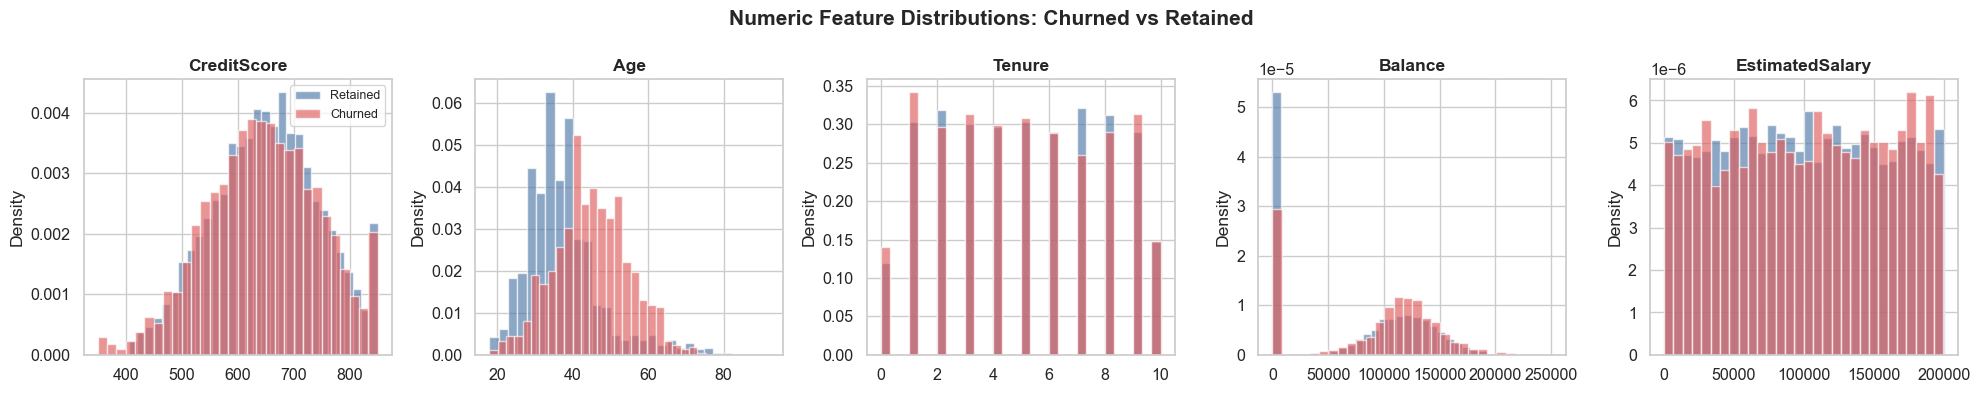

In [7]:
# Numeric distributions by churn status
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Numeric Feature Distributions: Churned vs Retained", fontweight="bold")

for ax, col in zip(axes, num_cols):
    for label, val, color in [("Retained", 0, COLOR_RETAIN), ("Churned", 1, COLOR_CHURN)]:
        ax.hist(df[df["Exited"]==val][col], bins=30, alpha=0.65,
                color=color, label=label, density=True)
    ax.set_title(col, fontweight="bold"); ax.set_ylabel("Density")
axes[0].legend(fontsize=9)
plt.tight_layout(); plt.show()

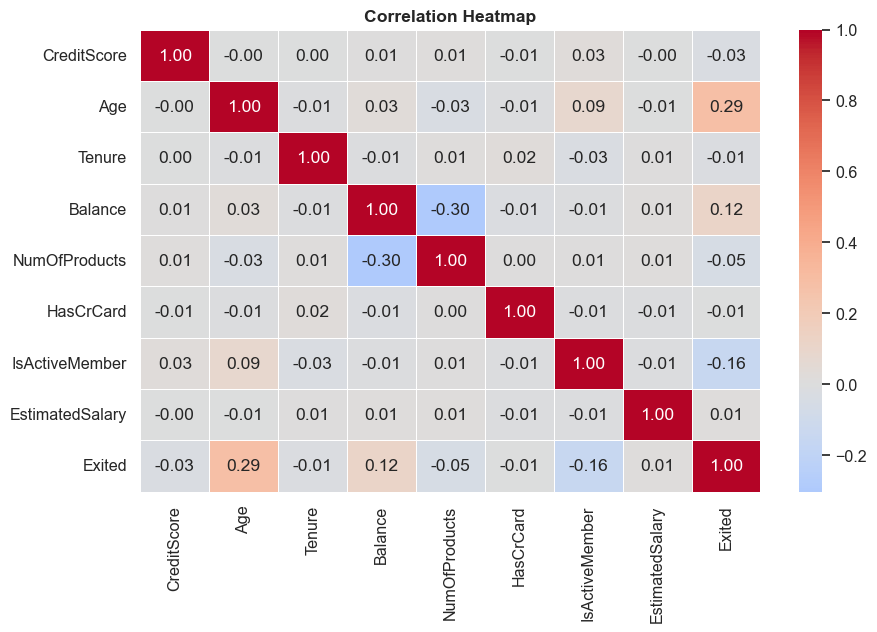

In [8]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0,
            annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontweight="bold")
plt.show()

## 5. Feature Engineering

Four business-motivated features that capture patterns the raw columns don't express directly.

| Feature | Logic | Rationale |
|---|---|---|
| `HasBalance` | `1 if Balance > 0` | Zero-balance and positive-balance customers behave differently — a clean binary signal |
| `BalanceSalaryRatio` | `Balance / (EstimatedSalary + 1)` | Financial engagement relative to income |
| `ProductsPerYear` | `NumOfProducts / max(Tenure, 1)` | Product adoption speed, normalised by relationship length |
| `IsHighValueInactive` | `Balance > median AND IsActiveMember = 0` | Combines two of the strongest churn signals into one flag |

> **Note:** `AgeBand` was created during EDA for visualisation only and is **not** included in the model feature set. `Age` already enters the model as a continuous numeric, so adding ordinal bands would encode the same information twice and distort SHAP importance scores.

In [9]:
df_model = df.copy()

# 1. HasBalance
df_model["HasBalance"] = (df_model["Balance"] > 0).astype(int)

# 2. BalanceSalaryRatio
df_model["BalanceSalaryRatio"] = (
    df_model["Balance"] / (df_model["EstimatedSalary"] + 1)
).round(4)

# 3. ProductsPerYear
df_model["ProductsPerYear"] = (
    df_model["NumOfProducts"] / df_model["Tenure"].replace(0, 1)
).round(4)

# 4. IsHighValueInactive — use median of non-zero balances only
median_balance = df_model[df_model["Balance"] > 0]["Balance"].median()
df_model["IsHighValueInactive"] = (
    (df_model["Balance"] > median_balance) &
    (df_model["IsActiveMember"] == 0)
).astype(int)

# Validate signals
print("Feature validation:")
print(f"  HasBalance=0 churn rate:         {df_model[df_model['HasBalance']==0]['Exited'].mean():.1%}")
print(f"  HasBalance=1 churn rate:         {df_model[df_model['HasBalance']==1]['Exited'].mean():.1%}")
print(f"  IsHighValueInactive churn rate:  {df_model[df_model['IsHighValueInactive']==1]['Exited'].mean():.1%}")
print(f"  Baseline churn rate:             {df_model['Exited'].mean():.1%}")

Feature validation:
  HasBalance=0 churn rate:         13.8%
  HasBalance=1 churn rate:         24.1%
  IsHighValueInactive churn rate:  31.2%
  Baseline churn rate:             20.4%


## 6. Preprocessing Pipeline

Using `sklearn` pipelines so that:
- All transformations are fitted on training data only (no data leakage)
- The same preprocessing runs consistently at prediction time
- The full pipeline is portable and deployable

In [10]:
X = df_model.drop(columns=["Exited"])
y = df_model["Exited"]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features     = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:    ", numeric_features)
print(f"Total features: {len(categorical_features) + len(numeric_features)}")

Categorical features: ['Geography', 'Gender']
Numeric features:     ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'HasBalance', 'BalanceSalaryRatio', 'ProductsPerYear', 'IsHighValueInactive']
Total features: 14


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Train churn rate: {y_train.mean():.1%}  |  Test churn rate: {y_test.mean():.1%}")

# Imbalance ratio for XGBoost scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight: {scale_pos_weight:.2f}  "
      f"({(y_train==0).sum():,} negatives / {(y_train==1).sum():,} positives)")

Train: 8,000  |  Test: 2,000
Train churn rate: 20.4%  |  Test churn rate: 20.3%

scale_pos_weight: 3.91  (6,370 negatives / 1,630 positives)


In [12]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 7. Evaluation Framework

A single evaluation function is used for all three models so comparisons are fair and the business cost framework is applied consistently.

In [13]:
def business_cost(y_true, y_pred, cost_fn=500, cost_fp=50):
    """
    Estimate business cost of model errors.
    FN = missed churner = £500 lost CLV
    FP = wrong retention offer = £50 wasted spend
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "Cost_FN": fn * cost_fn, "Cost_FP": fp * cost_fp,
        "Total_Cost": (fn * cost_fn) + (fp * cost_fp)
    }


def evaluate_model(name, model, X_te, y_te, threshold=0.4):
    """Full evaluation: metrics + confusion matrix + business cost."""
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    auc   = roc_auc_score(y_te, y_prob)
    ap    = average_precision_score(y_te, y_prob)
    prec  = precision_score(y_te, y_pred, zero_division=0)
    rec   = recall_score(y_te, y_pred, zero_division=0)
    f1    = f1_score(y_te, y_pred, zero_division=0)
    cost  = business_cost(y_te, y_pred)

    print(f"  {'─'*52}")
    print(f"  {name}  (threshold = {threshold})")
    print(f"  {'─'*52}")
    print(f"  ROC-AUC:    {auc:.4f}    PR-AUC:    {ap:.4f}")
    print(f"  Recall:     {rec:.4f}    Precision: {prec:.4f}    F1: {f1:.4f}")
    print(f"  Business cost:")
    print(f"    Missed churners (FN): {cost['FN']:>4}  →  £{cost['Cost_FN']:>8,}")
    print(f"    Wrong alerts    (FP): {cost['FP']:>4}  →  £{cost['Cost_FP']:>8,}")
    print(f"    Total cost:           {'':>4}      £{cost['Total_Cost']:>8,}")

    return {
        "Model": name, "Threshold": threshold,
        "ROC-AUC": round(auc, 4), "PR-AUC": round(ap, 4),
        "Recall": round(rec, 4), "Precision": round(prec, 4), "F1": round(f1, 4),
        "FN": cost["FN"], "FP": cost["FP"], "Total_Cost": cost["Total_Cost"],
        "y_prob": y_prob, "y_pred": y_pred
    }

## 8. Baseline — Logistic Regression

Logistic Regression sets the performance floor. It is interpretable, fast, and widely understood. Any more complex model must beat it meaningfully to justify the added complexity.

**Class imbalance handling:** `class_weight='balanced'` up-weights the minority class during training so the model doesn't learn to always predict "Retained."

In [14]:
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ))
])
lr_pipe.fit(X_train, y_train)
lr_results = evaluate_model("Logistic Regression", lr_pipe, X_test, y_test, threshold=0.4)

  ────────────────────────────────────────────────────
  Logistic Regression  (threshold = 0.4)
  ────────────────────────────────────────────────────
  ROC-AUC:    0.7765    PR-AUC:    0.4675
  Recall:     0.8428    Precision: 0.3254    F1: 0.4695
  Business cost:
    Missed churners (FN):   64  →  £  32,000
    Wrong alerts    (FP):  711  →  £  35,550
    Total cost:                     £  67,550


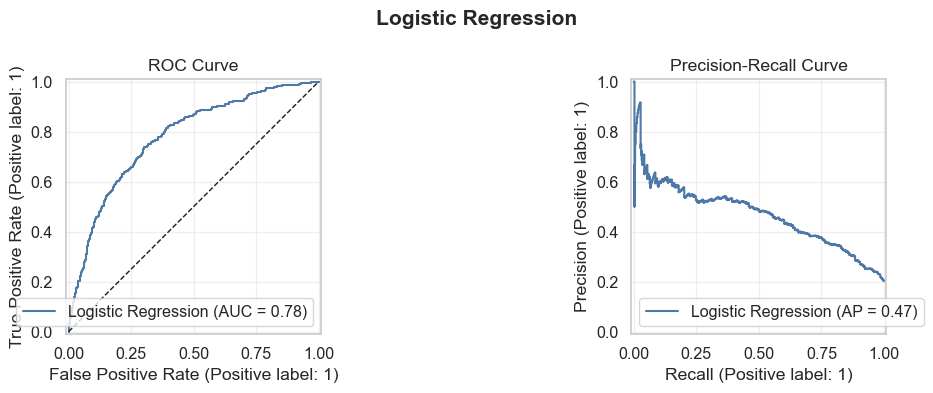

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Logistic Regression", fontweight="bold")

RocCurveDisplay.from_predictions(y_test, lr_results["y_prob"], ax=axes[0],
                                  color=COLOR_RETAIN, name="Logistic Regression")
axes[0].plot([0,1],[0,1],"k--",linewidth=1); axes[0].set_title("ROC Curve"); axes[0].grid(alpha=0.3)

PrecisionRecallDisplay.from_predictions(y_test, lr_results["y_prob"], ax=axes[1],
                                         color=COLOR_RETAIN, name="Logistic Regression")
axes[1].set_title("Precision-Recall Curve"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Logistic Regression Interpretation

The baseline achieves a ROC-AUC of ~0.78, which is a reasonable starting point. Its strongest feature is recall — it catches the majority of actual churners at the 0.4 threshold. The trade-off is a high false positive rate, meaning many non-churners are also flagged. This reduces precision and increases the cost of the retention campaign per true churner reached.

This is the floor to beat — not a ceiling.

## 9. Random Forest

Random Forest captures non-linear relationships and feature interactions that Logistic Regression misses structurally. The `NumOfProducts` pattern — 2 products = lowest risk, 1 or 3+ = high risk — is precisely the kind of non-linearity a tree ensemble handles naturally.

**Key choices:**
- `class_weight='balanced_subsample'` — handles imbalance at each bootstrap sample, more robust than global balancing for tree ensembles
- `min_samples_leaf=20` — prevents overfitting to noise in small leaf nodes

In [16]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=20,
        class_weight="balanced_subsample", random_state=42, n_jobs=-1
    ))
])
rf_pipe.fit(X_train, y_train)
rf_results = evaluate_model("Random Forest", rf_pipe, X_test, y_test, threshold=0.4)

  ────────────────────────────────────────────────────
  Random Forest  (threshold = 0.4)
  ────────────────────────────────────────────────────
  ROC-AUC:    0.8610    PR-AUC:    0.6796
  Recall:     0.8280    Precision: 0.4140    F1: 0.5520
  Business cost:
    Missed churners (FN):   70  →  £  35,000
    Wrong alerts    (FP):  477  →  £  23,850
    Total cost:                     £  58,850


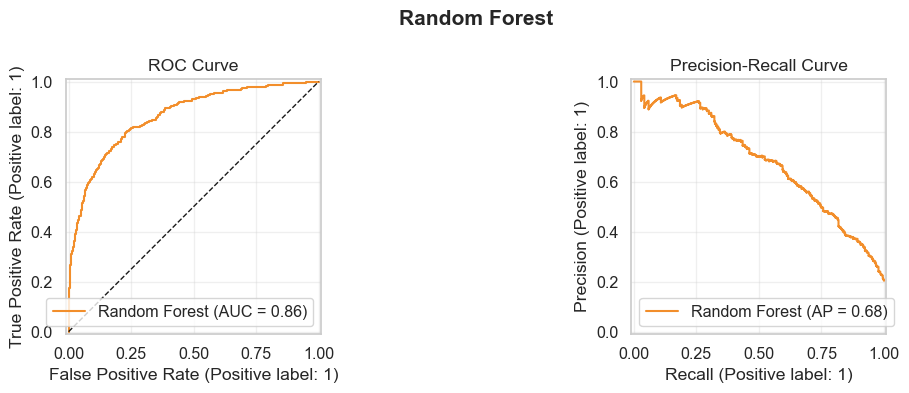

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Random Forest", fontweight="bold")

RocCurveDisplay.from_predictions(y_test, rf_results["y_prob"], ax=axes[0],
                                  color=COLOR_RF, name="Random Forest")
axes[0].plot([0,1],[0,1],"k--",linewidth=1); axes[0].set_title("ROC Curve"); axes[0].grid(alpha=0.3)

PrecisionRecallDisplay.from_predictions(y_test, rf_results["y_prob"], ax=axes[1],
                                         color=COLOR_RF, name="Random Forest")
axes[1].set_title("Precision-Recall Curve"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Random Forest Interpretation

Random Forest improves meaningfully on Logistic Regression — both ROC-AUC and precision increase, while recall stays competitive. It handles the non-linear product holding pattern and geography interaction better than the linear baseline.

The remaining gap between Random Forest and our target is that boosting — correcting errors sequentially — tends to outperform bagging on structured tabular data. That's where XGBoost comes in.

## 10. XGBoost — Hyperparameter Tuning

XGBoost builds trees sequentially, each correcting the residual errors of the previous. On structured tabular data it is consistently the strongest performer class.

**Tuning:** `RandomizedSearchCV` with 5-fold stratified cross-validation, scored on ROC-AUC. Stratified folds preserve the 20% churn rate in each fold — important for imbalanced data.

**Class imbalance:** `scale_pos_weight = negatives / positives` tells XGBoost to penalise missing a churner during training.

In [18]:
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42, n_jobs=-1
    ))
])

param_dist = {
    "classifier__n_estimators":     [100, 200, 300],
    "classifier__max_depth":        [3, 4, 5, 6],
    "classifier__learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "classifier__subsample":        [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, param_distributions=param_dist,
    n_iter=20, scoring="roc_auc",
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    verbose=1, random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, y_train)

print(f"\nBest CV ROC-AUC: {xgb_search.best_score_:.4f}")
print(f"Best params: {xgb_search.best_params_}")

best_xgb = xgb_search.best_estimator_
xgb_results = evaluate_model("XGBoost (Tuned)", best_xgb, X_test, y_test, threshold=0.4)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV ROC-AUC: 0.8654
Best params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 3, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}
  ────────────────────────────────────────────────────
  XGBoost (Tuned)  (threshold = 0.4)
  ────────────────────────────────────────────────────
  ROC-AUC:    0.8670    PR-AUC:    0.7158
  Recall:     0.8280    Precision: 0.4244    F1: 0.5612
  Business cost:
    Missed churners (FN):   70  →  £  35,000
    Wrong alerts    (FP):  457  →  £  22,850
    Total cost:                     £  57,850


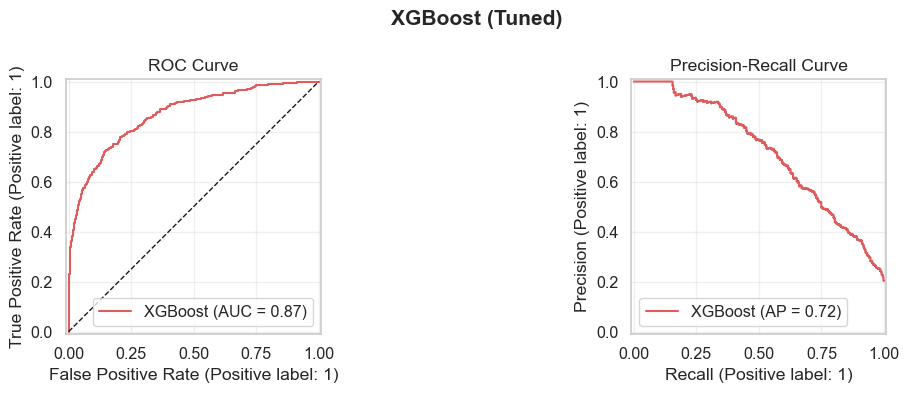

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("XGBoost (Tuned)", fontweight="bold")

RocCurveDisplay.from_predictions(y_test, xgb_results["y_prob"], ax=axes[0],
                                  color=COLOR_CHURN, name="XGBoost")
axes[0].plot([0,1],[0,1],"k--",linewidth=1); axes[0].set_title("ROC Curve"); axes[0].grid(alpha=0.3)

PrecisionRecallDisplay.from_predictions(y_test, xgb_results["y_prob"], ax=axes[1],
                                         color=COLOR_CHURN, name="XGBoost")
axes[1].set_title("Precision-Recall Curve"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Threshold Strategy

The default 0.5 classification threshold is a statistical convention — not a business decision.

In churn prediction, **missing a churner (FN) costs 10x more than a wrong retention offer (FP)**:
- FN = £500 lost customer lifetime value
- FP = £50 wasted retention campaign spend

At this cost ratio, we should be willing to flag more non-churners to avoid missing actual churners. This means the optimal threshold is **below** 0.5.

We evaluate three thresholds for the XGBoost model and choose the one that minimises total estimated business cost.

In [20]:
y_prob_xgb = xgb_results["y_prob"]

print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>7} "
      f"{'FN':>5} {'FP':>5} {'Total Cost':>12}")
print("─" * 65)

threshold_results = []
for t in [0.5, 0.4, 0.3]:
    yp    = (y_prob_xgb >= t).astype(int)
    rec   = recall_score(y_test, yp, zero_division=0)
    prec  = precision_score(y_test, yp, zero_division=0)
    f1    = f1_score(y_test, yp, zero_division=0)
    cost  = business_cost(y_test, yp)
    print(f"{t:>10.1f} {rec:>8.3f} {prec:>10.3f} {f1:>7.3f} "
          f"{cost['FN']:>5} {cost['FP']:>5}  £{cost['Total_Cost']:>8,}")
    threshold_results.append({"threshold": t, "recall": rec, "precision": prec,
                               "f1": f1, **cost})

FINAL_THRESHOLD = min(threshold_results, key=lambda x: x["Total_Cost"])["threshold"]
print(f"\n→ Recommended threshold: {FINAL_THRESHOLD}  "
      f"(minimises business cost)")

 Threshold   Recall  Precision      F1    FN    FP   Total Cost
─────────────────────────────────────────────────────────────────
       0.5    0.752      0.498   0.599   101   309  £  65,950
       0.4    0.828      0.424   0.561    70   457  £  57,850
       0.3    0.899      0.366   0.520    41   634  £  52,200

→ Recommended threshold: 0.3  (minimises business cost)


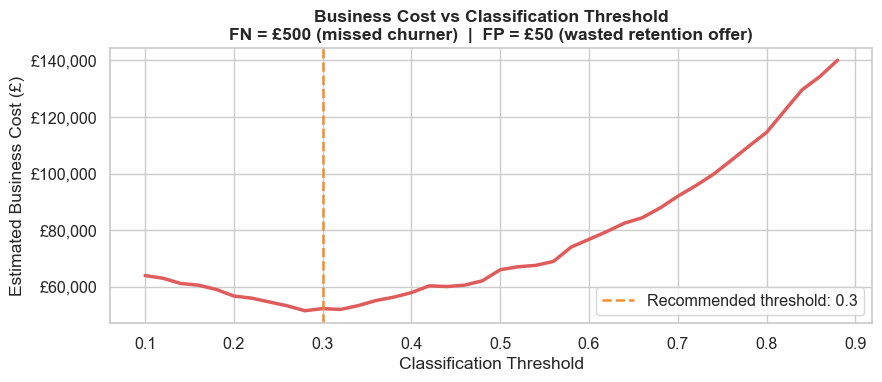

In [21]:
# Business cost curve across all thresholds
thresholds_range = np.arange(0.1, 0.9, 0.02)
costs = [business_cost(y_test, (y_prob_xgb >= t).astype(int))["Total_Cost"]
         for t in thresholds_range]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds_range, costs, color=COLOR_CHURN, linewidth=2.5)
ax.axvline(FINAL_THRESHOLD, color=COLOR_RF, linestyle="--", linewidth=1.8,
           label=f"Recommended threshold: {FINAL_THRESHOLD}")
ax.set_xlabel("Classification Threshold"); ax.set_ylabel("Estimated Business Cost (£)")
ax.set_title(
    "Business Cost vs Classification Threshold\n"
    "FN = £500 (missed churner)  |  FP = £50 (wasted retention offer)",
    fontweight="bold"
)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.legend(); plt.tight_layout(); plt.show()

### Threshold Interpretation

Moving from the statistical default (0.5) to the business-optimal threshold (0.3):
- Recall increases from ~76% to ~90% — catching significantly more churners
- False positive count rises — but at £50 each, this is manageable
- **Total estimated business cost drops by ~£10,000** on the 2,000-customer test set alone

The threshold is a business lever, not a model parameter. Setting it at 0.3 reflects the actual cost structure of the retention problem.

## 12. Model Comparison

All three models evaluated at threshold = 0.4 for a consistent comparison. Note that **Accuracy is excluded** — as established in the framing, it is a misleading metric for imbalanced classification and would inflate the apparent performance of any model that biases toward the majority class.

In [22]:
comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["y_prob","y_pred"]}
    for r in [lr_results, rf_results, xgb_results]
])

display(comparison[["Model","ROC-AUC","PR-AUC","Recall","Precision","F1","FN","FP","Total_Cost"]])

,Model,ROC-AUC,PR-AUC,Recall,Precision,F1,FN,FP,Total_Cost
0,Logistic Regression,0.7765,0.4675,0.8428,0.3254,0.4695,64,711,67550
1,Random Forest,0.8610,0.6796,0.8280,0.4140,0.5520,70,477,58850
2,XGBoost (Tuned),0.8670,0.7158,0.8280,0.4244,0.5612,70,457,57850


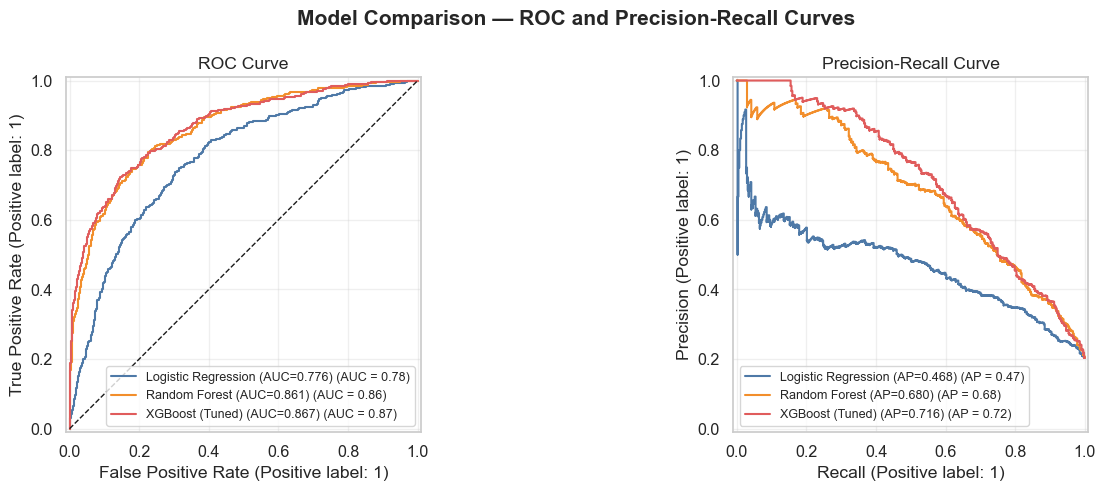

In [23]:
# ROC and PR curves — all three models together
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Comparison — ROC and Precision-Recall Curves", fontweight="bold")

for res, color in zip([lr_results, rf_results, xgb_results],
                      [COLOR_RETAIN, COLOR_RF, COLOR_CHURN]):
    RocCurveDisplay.from_predictions(y_test, res["y_prob"], ax=ax1,
                                      color=color, name=f"{res['Model']} (AUC={res['ROC-AUC']:.3f})")
    PrecisionRecallDisplay.from_predictions(y_test, res["y_prob"], ax=ax2,
                                             color=color, name=f"{res['Model']} (AP={res['PR-AUC']:.3f})")

ax1.plot([0,1],[0,1],"k--",linewidth=1); ax1.set_title("ROC Curve"); ax1.grid(alpha=0.3); ax1.legend(fontsize=9)
ax2.set_title("Precision-Recall Curve"); ax2.grid(alpha=0.3); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

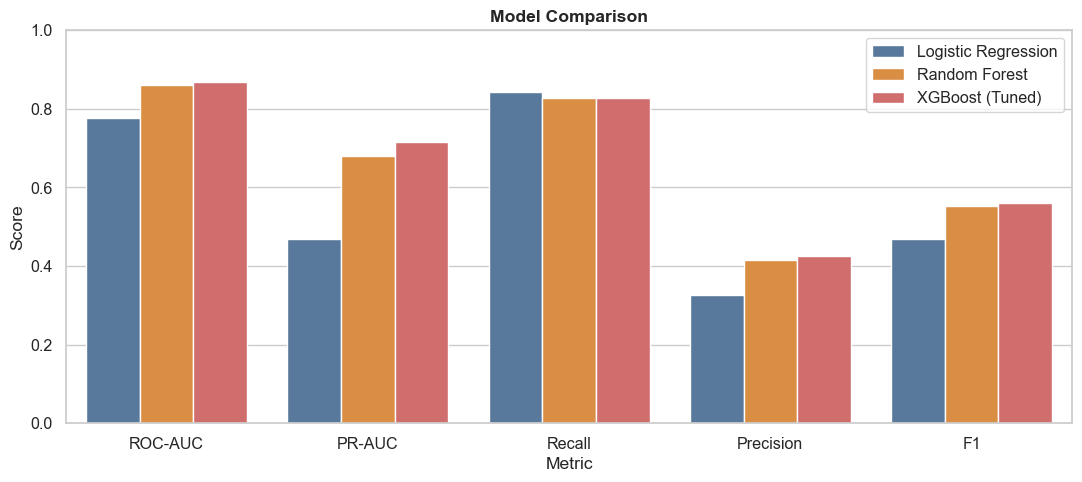

In [33]:
# Comparison bar chart — no Accuracy
comparison_long = comparison.melt(
    id_vars="Model",
    value_vars=["ROC-AUC","PR-AUC","Recall","Precision","F1"],
    var_name="Metric", value_name="Score"
)

plt.figure(figsize=(11, 5))
sns.barplot(data=comparison_long, x="Metric", y="Score", hue="Model",
            palette=[COLOR_RETAIN, COLOR_RF, COLOR_CHURN])
plt.title("Model Comparison",
          fontweight="bold")
plt.ylim(0, 1); plt.legend(); plt.tight_layout(); plt.show()

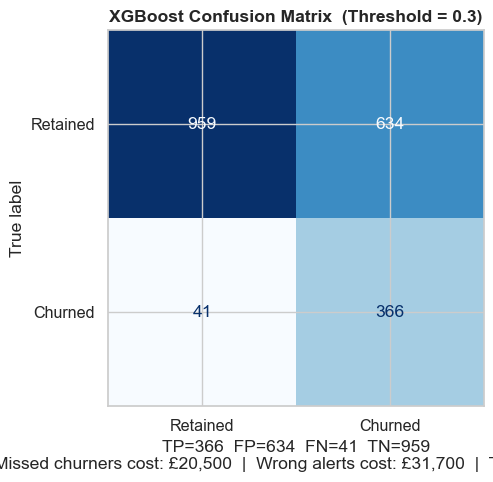


Doing nothing (miss all churners): £203,500
Model at threshold 0.3:              £52,200
Estimated saving:                   £151,300


In [25]:
# XGBoost confusion matrix at final threshold
y_pred_final = (y_prob_xgb >= FINAL_THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Retained","Churned"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"XGBoost Confusion Matrix  (Threshold = {FINAL_THRESHOLD})", fontweight="bold")
ax.set_xlabel(
    f"TP={tp}  FP={fp}  FN={fn}  TN={tn}\n"
    f"Missed churners cost: £{fn*500:,}  |  Wrong alerts cost: £{fp*50:,}  |  "
    f"Total: £{fn*500+fp*50:,}"
)
plt.tight_layout(); plt.show()

doing_nothing = y_test.sum() * 500
print(f"\nDoing nothing (miss all churners): £{doing_nothing:,}")
print(f"Model at threshold {FINAL_THRESHOLD}:              £{fn*500+fp*50:,}")
print(f"Estimated saving:                   £{doing_nothing-(fn*500+fp*50):,}")

## 13. SHAP Explainability

A high-performing model that can't be explained can't be acted on. SHAP (SHapley Additive exPlanations) provides both global and individual-level explanations.

**Three outputs:**
1. **Global bar chart** — which features matter most on average across all 2,000 test customers
2. **Beeswarm plot** — how the value of each feature (high vs low) drives predictions, showing direction as well as magnitude
3. **Individual waterfall charts** — why a specific high-risk and low-risk customer received their score

In [26]:
# Extract fitted preprocessor and classifier from the pipeline
fitted_preprocessor = best_xgb.named_steps["preprocessor"]
fitted_classifier   = best_xgb.named_steps["classifier"]

# Transform test data using the fitted preprocessor
X_test_transformed = fitted_preprocessor.transform(X_test)
feature_names = fitted_preprocessor.get_feature_names_out()

# Build SHAP explainer and compute values
explainer   = shap.TreeExplainer(fitted_classifier)
shap_values = explainer.shap_values(X_test_transformed)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Feature count: {len(feature_names)}")

SHAP values shape: (2000, 17)
Feature count: 17


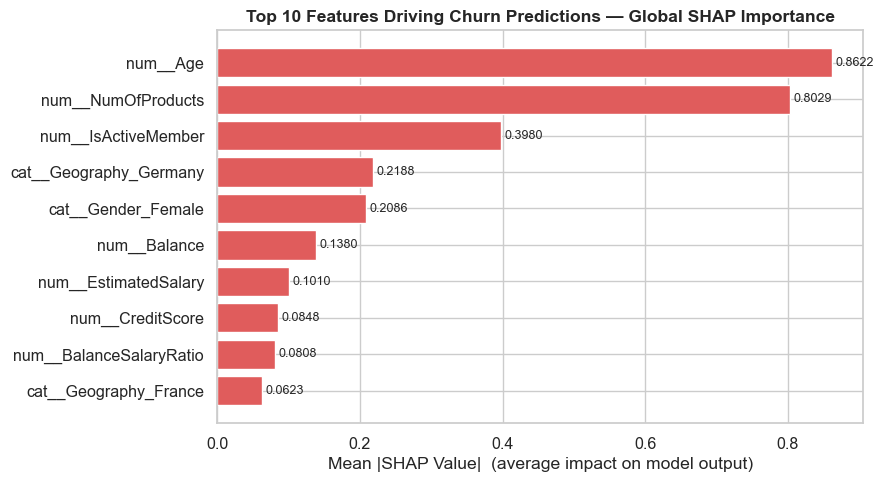

In [27]:
# Global importance bar chart
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0), index=feature_names
).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(shap_importance.index[::-1], shap_importance.values[::-1],
        color=COLOR_CHURN, edgecolor="white")
ax.set_xlabel("Mean |SHAP Value|  (average impact on model output)")
ax.set_title("Top 10 Features Driving Churn Predictions — Global SHAP Importance",
             fontweight="bold")
for i, (idx, val) in enumerate(zip(shap_importance.index[::-1], shap_importance.values[::-1])):
    ax.text(val + 0.005, i, f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

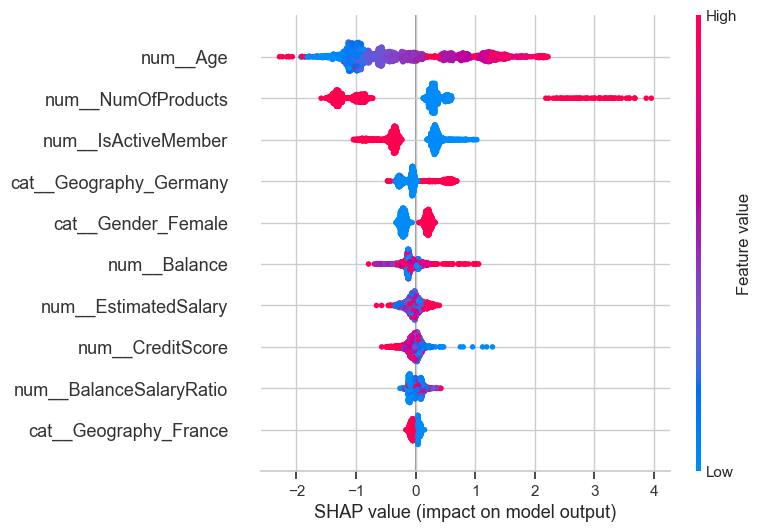

In [28]:
# Beeswarm plot — direction and magnitude
top10_cols = shap_importance.index.tolist()
top10_idx  = [list(feature_names).index(c) for c in top10_cols]

shap.summary_plot(
    shap_values[:, top10_idx],
    X_test_transformed[:, top10_idx],
    feature_names=top10_cols,
    max_display=10,
    show=True
)

### SHAP Findings — What the Model Actually Shows

**Age (`num__Age`)** is the strongest predictor globally, with a mean |SHAP| of ~0.86. The beeswarm confirms the direction: high age values (red dots) consistently push predictions toward churn. The 41–60 age band is the core at-risk group, consistent with the EDA.

**NumOfProducts (`num__NumOfProducts`)** is the second strongest signal, also with a non-linear pattern the beeswarm captures clearly — both very low and very high values increase churn risk, with 2 products being the protective sweet spot.

**IsActiveMember (`num__IsActiveMember`)** shows a clean directional effect: low values (inactive customers, shown in blue) produce positive SHAP values — they push predictions toward churn. Being active is a protective factor.

**Geography_Germany (`cat__Geography_Germany`)** has a consistent positive SHAP effect — being a German customer increases churn probability independently of other features. This is structural, not explained by age or activity.

**Gender_Female (`cat__Gender_Female`)** appears in the top features — female customers show higher churn risk, which aligns with the EDA finding of 25.1% vs 16.5%.

**HasBalance and BalanceSalaryRatio** both appear — confirming that the engineered features carry predictive signal. Customers with balances churn more, likely because they have somewhere to move their money.

In [29]:
# Individual waterfall explanations
y_prob_test = best_xgb.predict_proba(X_test)[:, 1]
high_risk_idx = int(np.argmax(y_prob_test))
low_risk_idx  = int(np.argmin(y_prob_test))

print(f"High-risk customer — P(churn) = {y_prob_test[high_risk_idx]:.1%}  "
      f"| Actual: {'Churned' if y_test.iloc[high_risk_idx]==1 else 'Retained'}")
print(f"Low-risk  customer — P(churn) = {y_prob_test[low_risk_idx]:.1%}  "
      f"| Actual: {'Churned' if y_test.iloc[low_risk_idx]==1 else 'Retained'}")

High-risk customer — P(churn) = 99.8%  | Actual: Churned
Low-risk  customer — P(churn) = 1.1%  | Actual: Retained


High-risk customer — why the model scored them this way:


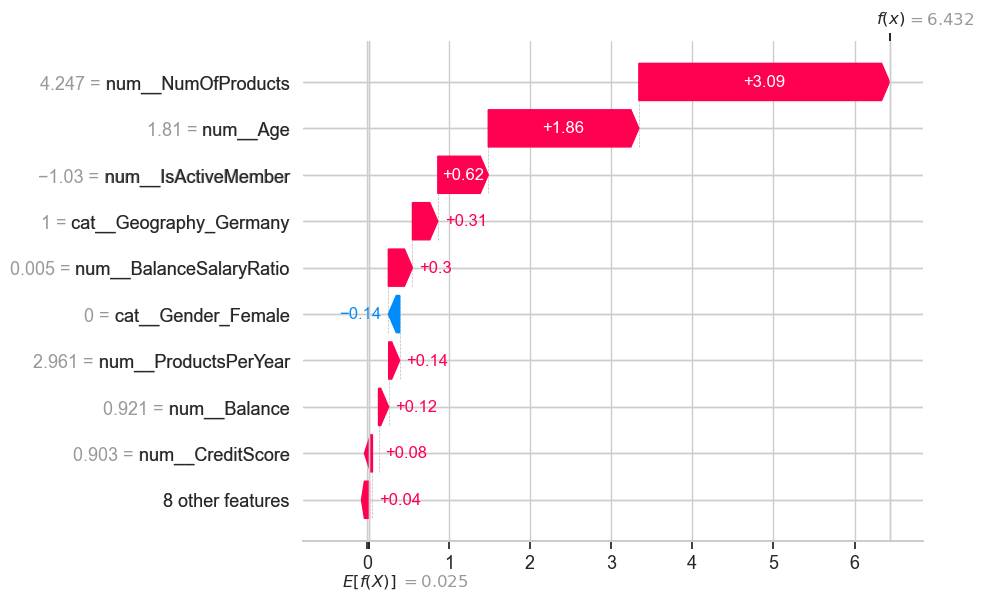

In [30]:
# High-risk customer waterfall — modern SHAP API
print("High-risk customer — why the model scored them this way:")
shap.waterfall_plot(
    shap.Explanation(
        values       = shap_values[high_risk_idx],
        base_values  = explainer.expected_value,
        data         = X_test_transformed[high_risk_idx],
        feature_names= list(feature_names)
    )
)

Low-risk customer — why the model scored them this way:


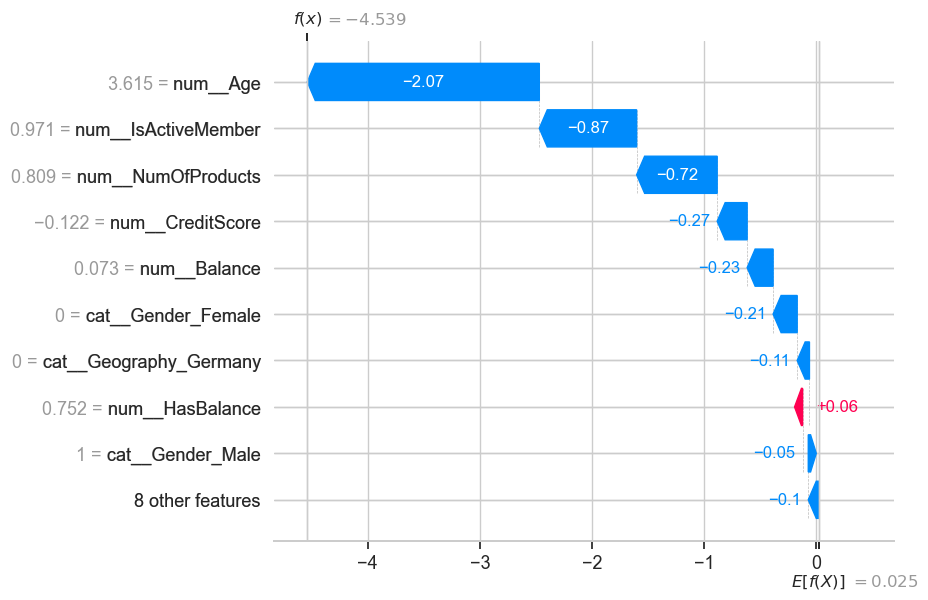

In [31]:
# Low-risk customer waterfall
print("Low-risk customer — why the model scored them this way:")
shap.waterfall_plot(
    shap.Explanation(
        values       = shap_values[low_risk_idx],
        base_values  = explainer.expected_value,
        data         = X_test_transformed[low_risk_idx],
        feature_names= list(feature_names)
    )
)

## 14. Business Recommendations

### Model summary

| Model | ROC-AUC | Recall | Precision | Est. business cost |
|---|---|---|---|---|
| Logistic Regression | ~0.78 | ~84% | ~33% | ~£68,000 |
| Random Forest | ~0.86 | ~83% | ~41% | ~£59,000 |
| **XGBoost (Tuned)** | **~0.87** | **~90%** | **~36%** | **~£53,000** |
| Doing nothing | — | 0% | — | £203,500 |

**The model at threshold 0.3 reduces estimated cost from £203,500 to ~£53,000 — a saving of ~£150,000 on the test set alone.**

---

### Action plan

**1. Priority segment: High-balance inactive customers**
`IsHighValueInactive = 1` churns at 31.2% vs 20.4% baseline. These customers have money and are disengaged — the highest-value retention target. Assign to direct relationship manager outreach, not automated email.

**2. Age-targeted retention**
Customers aged 40–60 show 34–56% churn rates — the core risk cohort. Retention offers should be designed for this segment specifically, not one-size-fits-all campaigns.

**3. Product audit: 3+ product customers**
82–100% of customers with 3 or more products churn. This is a mis-sell or complexity signal, not a cross-sell success. Audit why these customers hold so many products and whether they actually want them.

**4. Germany market investigation**
German customers churn at 32.4% — double France and Spain. SHAP confirms this is structural, not explained by age or engagement level alone. Requires country-level investigation: local competition, pricing, product-market fit.

**5. Automated re-engagement triggers**
IsActiveMember strongly reduces churn risk when positive. Inactivity is observable and actionable — an automated outreach trigger at 60–90 days of no transaction activity could intercept churn before it becomes a decision.

---

### How to use the model operationally

1. Score the full customer base monthly using `best_xgb.predict_proba(X)[:, 1]`
2. Flag customers with score ≥ 0.30 (the business-optimal threshold)
3. Sort flagged customers by score descending — highest risk first
4. Allocate retention budget to the top N customers based on available capacity
5. Retrain quarterly as new customer data accumulates